In [1]:
import jax.numpy as jnp
import pandas as pd
import numpy as np

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression


In [2]:
# data-generating process
def generate_data(n):
    W = np.random.uniform(0, 1, n)
    Y_obs = np.random.normal(0, np.sqrt(0.5), n)
    X = np.zeros(n, dtype=int)
    
    probs = np.where(W > 0.5, 0.6, 0.4)
    treat_mask = np.random.uniform(0, 1, n) < probs
    
    X[treat_mask] = 1
    Y_obs[treat_mask] += 0.5 * (1 + W[treat_mask])
    
    return Y_obs, X, W

In [3]:
n = 100
y, x, w = generate_data(n)
Z = np.column_stack((x, w))

# fit conditional copula regression
fit = fit_copula_cregression(jnp.array(y),jnp.array(Z),single_x_bandwidth = False,n_perm_optim = 10)
print("Optimised rho: ", fit.rho_opt)
print("Optimised rho_x: ", fit.rho_x_opt)
print("Prequential log-likelihhod: ", fit.preq_loglik)





Compiling...
Compilation time: 2.298s
Optimizing...
Optimization time: 0.277s
Fitting...
Fit time: 0.01s
Optimised rho:  0.3120458
Optimised rho_x:  [0.9044123 0.7279857]
Prequential log-likelihhod:  -1.2213691473007202


In [4]:

# 1. Get unique values and treatment levels
w_unique = np.unique(w)
x_levels = np.array([0, 1])

# 2. Create the grid for Z (X and W)
# This results in a grid where every W is paired with X=0 and X=1
z_grid_x, z_grid_w = np.meshgrid(x_levels, w_unique)
z_plot_ravel = np.column_stack((z_grid_x.ravel(), z_grid_w.ravel()))

# 3. Create a y grid for density evaluation
y_plot = np.linspace(y.min() - 1, y.max() + 1, num=200)

# 4. Create the final 3D evaluation grid (y, x, w)
# We repeat Z for every value in y_plot
z_expanded = np.repeat(z_plot_ravel, len(y_plot), axis=0)
y_expanded = np.tile(y_plot, len(z_plot_ravel))

# Run Prediction
logcdf_cond, logpdf_joint = predict_copula_cregression(
    fit, 
    jnp.array(y_expanded), 
    jnp.array(z_expanded)
)



Predicting...
Prediction time: 2.027s


Predicting...
Prediction time: 0.67s
Predictive resampling...
Predictive resampling time: 11.704s
Predicting...
Prediction time: 0.761s
Predictive resampling...
Predictive resampling time: 12.342s


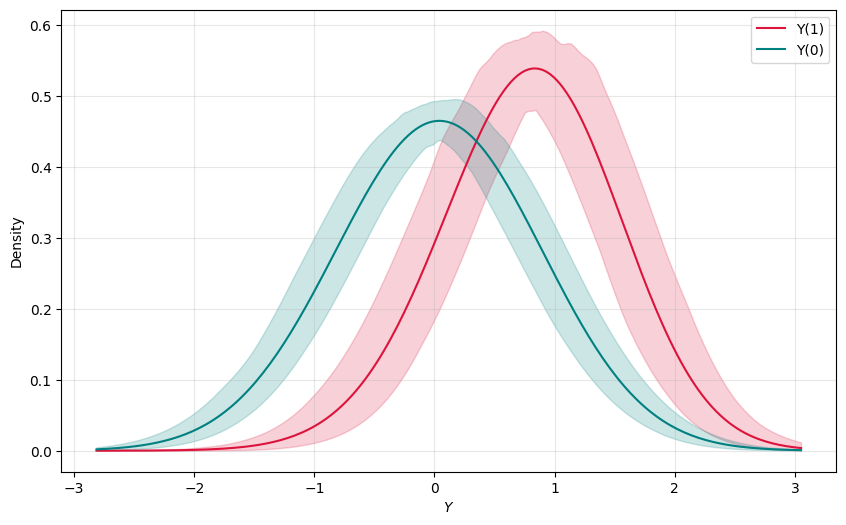

In [8]:
import matplotlib.pyplot as plt

w_val = 0.5
y_grid = np.linspace(y.min() - 1, y.max() + 1, 200)
T_fwd, B_post = 500, 100

# Precompute W values for indexing
Z_jnp = jnp.array(Z)
w_unique_jnp = jnp.array(w_unique)

def get_density_stats(x_val):
    # Build the test grid over y and all unique w values for fixed x_val
    n_w = len(w_unique_jnp)
    y_target = jnp.tile(jnp.array(y_grid), n_w)
    w_target = jnp.repeat(w_unique_jnp, len(y_grid))
    z_target = jnp.column_stack((jnp.repeat(float(x_val), y_target.shape[0]), w_target))

    _, logpdf_pr, ind_new_pr = predictive_resample_cregression(
        fit, jnp.array(Z), y_target, z_target, B_post, T_fwd, seed=42
    )

    logpdf_pr = jnp.squeeze(logpdf_pr)
    pdfs = jnp.exp(logpdf_pr)
    pdfs = pdfs.reshape(B_post, n_w, len(y_grid))

    sampled_w = Z_jnp[ind_new_pr, 1]
    weights = jnp.equal(sampled_w[:, :, None], w_unique_jnp[None, None, :]).sum(axis=1)
    weights = weights / weights.sum(axis=1, keepdims=True)

    marginal_pdfs = jnp.einsum('bw,bwy->by', weights, pdfs)

    return {
        'mean': np.array(jnp.mean(marginal_pdfs, axis=0)),
        'low':  np.array(jnp.quantile(marginal_pdfs, 0.025, axis=0)),
        'high': np.array(jnp.quantile(marginal_pdfs, 0.975, axis=0))
    }

res_t = get_density_stats(1)  # Treated
res_c = get_density_stats(0)  # Control

plt.figure(figsize=(10, 6))

# Plot Treated Group
plt.plot(y_grid, res_t['mean'], color='crimson', label=f'Y(1)')
plt.fill_between(y_grid, res_t['low'], res_t['high'], color='crimson', alpha=0.2)

# Plot Control Group
plt.plot(y_grid, res_c['mean'], color='teal', label=f'Y(0)')
plt.fill_between(y_grid, res_c['low'], res_c['high'], color='teal', alpha=0.2)

plt.xlabel('$Y$')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()